In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv("../data/ndvi_dataset.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (908, 27)
         lon       lat       label   ndvi_00   ndvi_01   ndvi_02   ndvi_03  \
0 -54.595477 -3.641303  deforested  0.870792  0.828480  0.867654  0.776213   
1 -54.571395 -3.615745  deforested  0.844116  0.838710  0.848954  0.760890   
2 -54.558029 -3.536081  deforested  0.867034  0.873003  0.878971  0.793343   
3 -54.651907 -3.637025  deforested  0.867872  0.843861  0.869378  0.846152   
4 -54.656760 -3.634666  deforested  0.889375  0.862412  0.886648  0.780126   

    ndvi_04   ndvi_05   ndvi_06  ...   ndvi_14   ndvi_15   ndvi_16   ndvi_17  \
0  0.695124  0.687961  0.680798  ...  0.414334  0.337451  0.378471  0.419491   
1  0.782955  0.635117  0.487280  ...  0.350414  0.330483  0.394602  0.408693   
2  0.437234  0.317441  0.197649  ...  0.459565  0.533148  0.606731  0.607890   
3  0.822926  0.735515  0.648103  ...  0.445805  0.496051  0.546298  0.540630   
4  0.839200  0.819455  0.799710  ...  0.429726  0.388753  0.363892  0.339032   

    ndvi_18   ndvi_19   n

In [3]:
ndvi_cols = [
    col for col in df.columns
    if col.startswith("ndvi_")
]

print("Number of NDVI time steps:", len(ndvi_cols))
print(ndvi_cols)

Number of NDVI time steps: 24
['ndvi_00', 'ndvi_01', 'ndvi_02', 'ndvi_03', 'ndvi_04', 'ndvi_05', 'ndvi_06', 'ndvi_07', 'ndvi_08', 'ndvi_09', 'ndvi_10', 'ndvi_11', 'ndvi_12', 'ndvi_13', 'ndvi_14', 'ndvi_15', 'ndvi_16', 'ndvi_17', 'ndvi_18', 'ndvi_19', 'ndvi_20', 'ndvi_21', 'ndvi_22', 'ndvi_23']


In [4]:
early_cols = ndvi_cols[:12]

X_early = df[early_cols].values
y_early = df["label"].values

print("Early observation columns:")
print(early_cols)

print("\nX_early shape:", X_early.shape)
print("y_early shape:", y_early.shape)

Early observation columns:
['ndvi_00', 'ndvi_01', 'ndvi_02', 'ndvi_03', 'ndvi_04', 'ndvi_05', 'ndvi_06', 'ndvi_07', 'ndvi_08', 'ndvi_09', 'ndvi_10', 'ndvi_11']

X_early shape: (908, 12)
y_early shape: (908,)


In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y_early)

print("Classes:", label_encoder.classes_)
print("Encoded labels:", np.unique(y_encoded))

Classes: ['deforested' 'forest' 'old_clearing']
Encoded labels: [0 1 2]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_early,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (726, 12)
X_test shape: (182, 12)
y_train shape: (726,)
y_test shape: (182,)


In [7]:
early_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

early_model.fit(X_train, y_train)

print("Early detection model trained successfully.")

Early detection model trained successfully.


In [8]:
early_pred = early_model.predict(X_test)

print("Predictions generated:", len(early_pred))

Predictions generated: 182


In [9]:
print("Early Detection Results")
print("-----------------------")

print(
    "Accuracy:",
    accuracy_score(y_test, early_pred)
)

print(
    "Macro Precision:",
    precision_score(
        y_test,
        early_pred,
        average="macro"
    )
)

print(
    "Macro Recall:",
    recall_score(
        y_test,
        early_pred,
        average="macro"
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        early_pred,
        average="macro"
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        early_pred,
        target_names=label_encoder.classes_
    )
)

Early Detection Results
-----------------------
Accuracy: 0.6758241758241759
Macro Precision: 0.5952455231796344
Macro Recall: 0.5357111274871039
Macro F1: 0.5485571587125416

Classification Report:
              precision    recall  f1-score   support

  deforested       0.36      0.17      0.24        23
      forest       0.68      0.84      0.75       100
old_clearing       0.74      0.59      0.66        59

    accuracy                           0.68       182
   macro avg       0.60      0.54      0.55       182
weighted avg       0.66      0.68      0.66       182



In [10]:
cm_early = confusion_matrix(y_test, early_pred)

print("Early Detection Confusion Matrix:")

print(
    pd.DataFrame(
        cm_early,
        index=[f"Actual {c}" for c in label_encoder.classes_],
        columns=[f"Pred {c}" for c in label_encoder.classes_]
    )
)

Early Detection Confusion Matrix:
                     Pred deforested  Pred forest  Pred old_clearing
Actual deforested                  4           18                  1
Actual forest                      5           84                 11
Actual old_clearing                2           22                 35


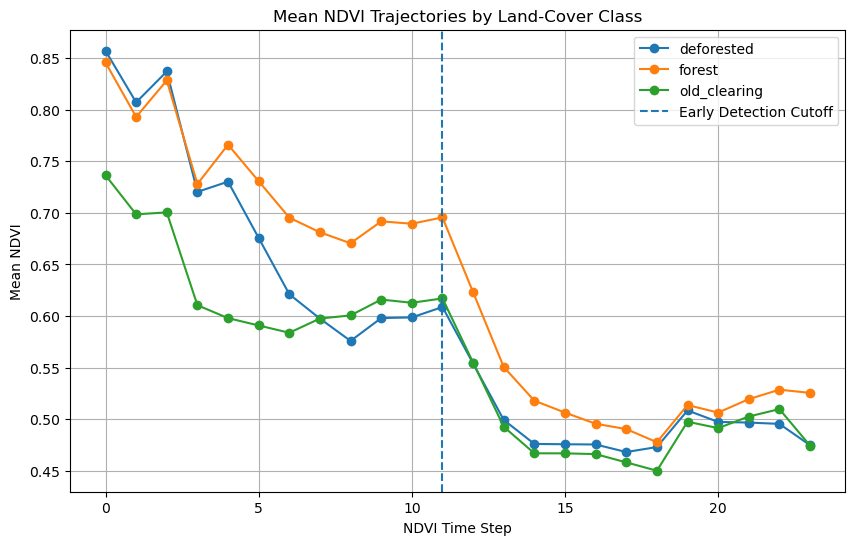

In [11]:
plt.figure(figsize=(10, 6))

for class_name in label_encoder.classes_:
    class_data = df[df["label"] == class_name][ndvi_cols]

    mean_ndvi = class_data.mean(axis=0)

    plt.plot(
        range(24),
        mean_ndvi,
        marker="o",
        label=class_name
    )

plt.axvline(
    x=11,
    linestyle="--",
    label="Early Detection Cutoff"
)

plt.xlabel("NDVI Time Step")
plt.ylabel("Mean NDVI")
plt.title("Mean NDVI Trajectories by Land-Cover Class")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
class_means = df.groupby("label")[ndvi_cols].mean()

print("Mean NDVI at each time step:")
print(class_means.round(3))

print("\nNDVI at early-detection cutoff (ndvi_11):")
print(class_means["ndvi_11"].round(3))

Mean NDVI at each time step:
              ndvi_00  ndvi_01  ndvi_02  ndvi_03  ndvi_04  ndvi_05  ndvi_06  \
label                                                                         
deforested      0.857    0.807    0.837    0.720    0.730    0.676    0.621   
forest          0.846    0.793    0.829    0.728    0.766    0.731    0.695   
old_clearing    0.737    0.699    0.701    0.610    0.598    0.591    0.584   

              ndvi_07  ndvi_08  ndvi_09  ...  ndvi_14  ndvi_15  ndvi_16  \
label                                    ...                              
deforested      0.598    0.576    0.598  ...    0.476    0.476    0.475   
forest          0.681    0.671    0.692  ...    0.518    0.506    0.496   
old_clearing    0.598    0.601    0.616  ...    0.467    0.467    0.466   

              ndvi_17  ndvi_18  ndvi_19  ndvi_20  ndvi_21  ndvi_22  ndvi_23  
label                                                                        
deforested      0.468    0.473    0.508    

In [13]:
cutoffs = [6, 8, 10, 12, 14, 16, 18, 20, 24]

early_results = []

for cutoff in cutoffs:

    X_window = df[ndvi_cols[:cutoff]].values

    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        X_window,
        y_encoded,
        test_size=0.20,
        random_state=42,
        stratify=y_encoded
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    model.fit(X_train_w, y_train_w)

    pred_w = model.predict(X_test_w)

    early_results.append({
        "Observations": cutoff,
        "Accuracy": accuracy_score(y_test_w, pred_w),
        "Macro Precision": precision_score(
            y_test_w, pred_w, average="macro"
        ),
        "Macro Recall": recall_score(
            y_test_w, pred_w, average="macro"
        ),
        "Macro F1": f1_score(
            y_test_w, pred_w, average="macro"
        ),
        "Deforested Recall": recall_score(
            y_test_w,
            pred_w,
            labels=[0],
            average=None
        )[0]
    })

early_results_df = pd.DataFrame(early_results)

print(early_results_df.round(3))

   Observations  Accuracy  Macro Precision  Macro Recall  Macro F1  \
0             6     0.659            0.529         0.501     0.502   
1             8     0.676            0.580         0.529     0.536   
2            10     0.643            0.513         0.489     0.489   
3            12     0.676            0.595         0.536     0.549   
4            14     0.670            0.558         0.526     0.532   
5            16     0.681            0.589         0.533     0.541   
6            18     0.681            0.571         0.530     0.537   
7            20     0.692            0.607         0.542     0.550   
8            24     0.720            0.687         0.603     0.626   

   Deforested Recall  
0              0.087  
1              0.130  
2              0.087  
3              0.174  
4              0.130  
5              0.130  
6              0.130  
7              0.130  
8              0.304  


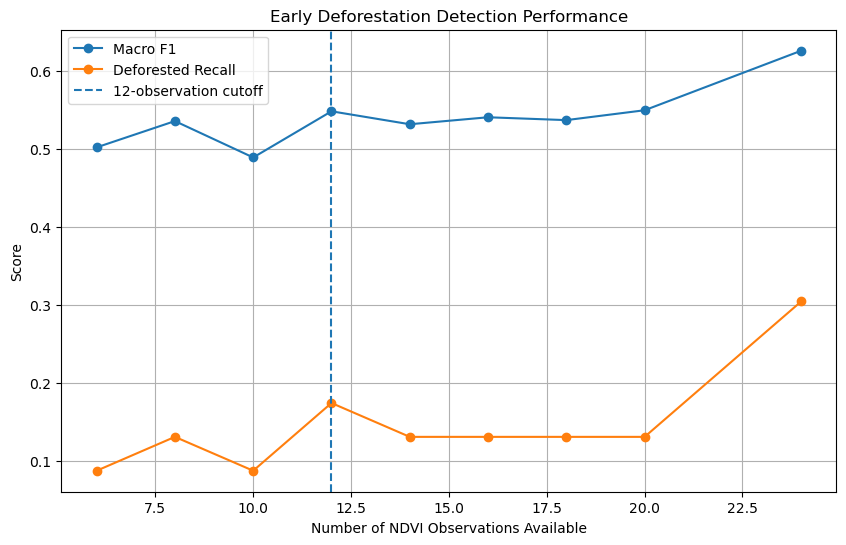

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    early_results_df["Observations"],
    early_results_df["Macro F1"],
    marker="o",
    label="Macro F1"
)

plt.plot(
    early_results_df["Observations"],
    early_results_df["Deforested Recall"],
    marker="o",
    label="Deforested Recall"
)

plt.axvline(
    x=12,
    linestyle="--",
    label="12-observation cutoff"
)

plt.xlabel("Number of NDVI Observations Available")
plt.ylabel("Score")
plt.title("Early Deforestation Detection Performance")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
early_results_df.to_csv(
    "../results/early_detection_results.csv",
    index=False
)

print("Saved:")
print("../results/early_detection_results.csv")

Saved:
../results/early_detection_results.csv


In [18]:
# Get the original test-set indices
_, test_indices = train_test_split(
    np.arange(len(df)),
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Create results only for the 182 test samples
early_prediction_df = df.iloc[test_indices][
    ["lon", "lat", "label"]
].copy()

# Add predictions
early_prediction_df["predicted_label"] = label_encoder.inverse_transform(
    early_pred
)

# Mark correct/incorrect predictions
early_prediction_df["correct"] = (
    early_prediction_df["label"]
    == early_prediction_df["predicted_label"]
)

# Save
early_prediction_df.to_csv(
    "../results/early_detection_predictions.csv",
    index=False
)

print("Saved successfully.")
print("Rows:", len(early_prediction_df))

print("\nPrediction counts:")
print(early_prediction_df["predicted_label"].value_counts())

print("\nErrors:", (~early_prediction_df["correct"]).sum())

Saved successfully.
Rows: 182

Prediction counts:
predicted_label
forest          124
old_clearing     47
deforested       11
Name: count, dtype: int64

Errors: 59


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load saved predictions
pred_df = pd.read_csv(
    "../results/early_detection_predictions.csv"
)

print("Prediction data shape:", pred_df.shape)
print(pred_df.head())

Prediction data shape: (182, 5)
         lon       lat         label predicted_label  correct
0 -54.745147 -3.545606  old_clearing    old_clearing     True
1 -54.586272 -3.682806    deforested          forest    False
2 -54.566265 -3.603391    deforested      deforested     True
3 -54.736702 -3.593060  old_clearing    old_clearing     True
4 -54.639314 -3.560016        forest          forest     True


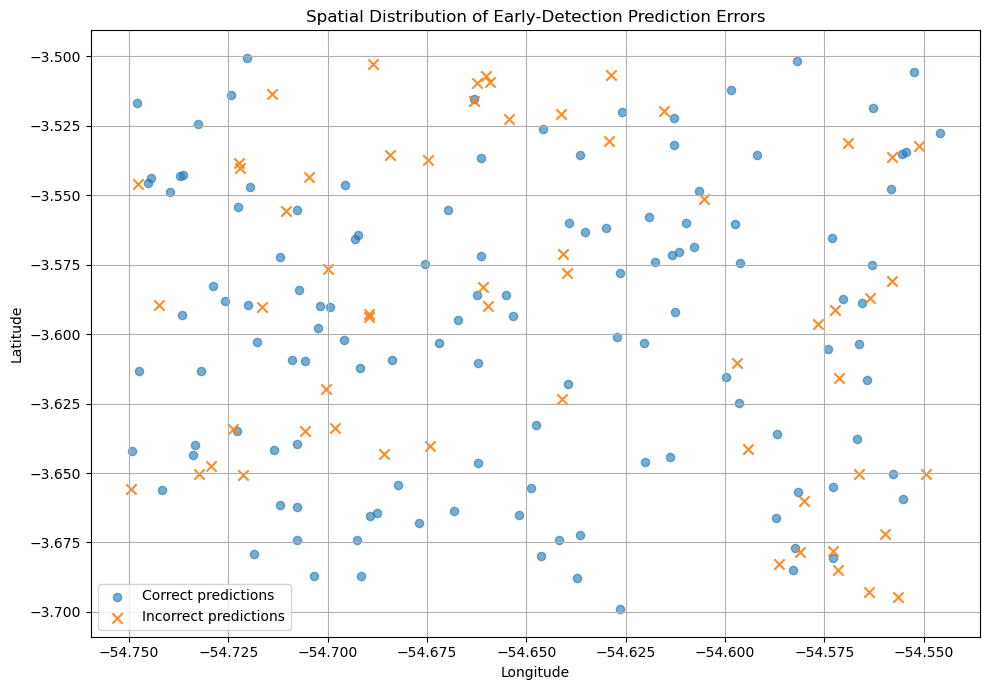

In [20]:
# Create spatial prediction-error map

plt.figure(figsize=(10, 7))

# Correct predictions
correct = pred_df[pred_df["correct"] == True]

# Incorrect predictions
errors = pred_df[pred_df["correct"] == False]

plt.scatter(
    correct["lon"],
    correct["lat"],
    label="Correct predictions",
    alpha=0.6,
    s=35
)

plt.scatter(
    errors["lon"],
    errors["lat"],
    label="Incorrect predictions",
    alpha=0.9,
    s=55,
    marker="x"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Early-Detection Prediction Errors")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/early_detection_error_spatial_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

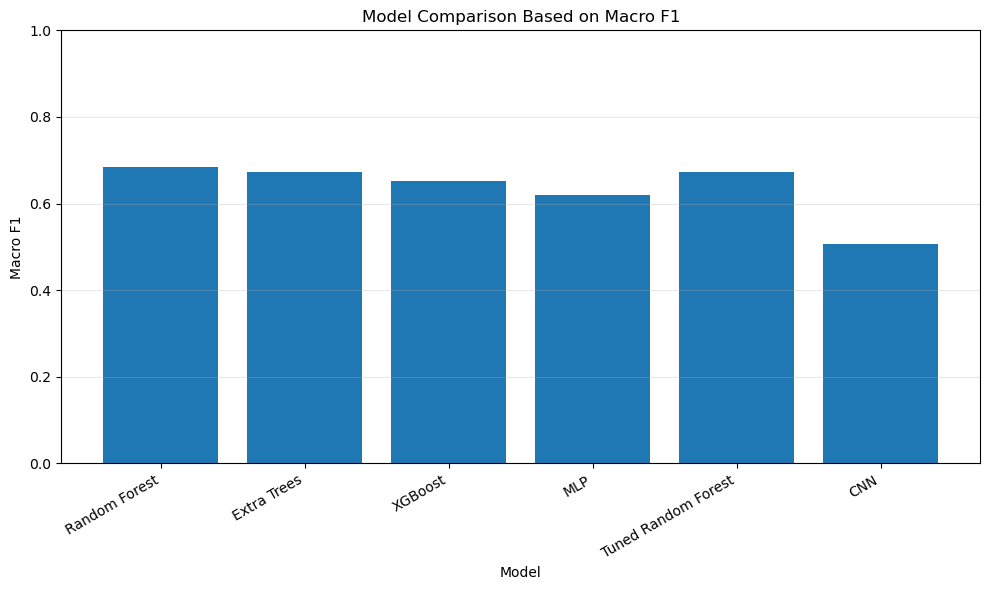

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# Load saved model comparison
comparison = pd.read_csv(
    "../results/model_comparison.csv"
)

# Plot Macro F1
plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Model"],
    comparison["Macro F1"]
)

plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.title("Model Comparison Based on Macro F1")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/model_comparison_macro_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()